In [4]:
import pandas as pd 
import re 
import numpy as np
#import pillow 
pd.set_option('display.max_colwidth', None)
from google.colab import files
files.upload()
#data = pd.read_csv('https://drive.google.com/file/d/1ZzgRhOeD8hcQbbBM9H6DwaJsphae8kCE/view?usp=sharing')

Saving newest_gm_reviews.csv to newest_gm_reviews (1).csv


{'newest_gm_reviews.csv': b'id_review,caption,relative_date,retrieval_date,rating,username,n_review_user,n_photo_user,url_user\r\nChdDSUhNMG9nS0VJQ0FnSURtel82TXlRRRAB,Passer prendre un verre rapidement entre 2 rendez-vous et finalement ne plus vouloir en sortir. Aller un dernier son et je pars et le barman aka Dj encha\xc3\xaene les titres,a day ago,2022-02-14 17:36:20.640681,5.0,Bolus Jonathan Kopdas,0,0,https://www.google.com/maps/contrib/104745591529904122578/reviews?hl=en-GB\r\nChdDSUhNMG9nS0VJQ0FnSURtcTlIZjFRRRAB,,5 days ago,2022-02-14 17:36:20.643246,5.0,A A,0,0,https://www.google.com/maps/contrib/109010883926058002463/reviews?hl=en-GB\r\nChZDSUhNMG9nS0VJQ0FnSURteTd6Sk9BEAE,,5 days ago,2022-02-14 17:36:20.647339,5.0,Bismuth Jennifer,0,0,https://www.google.com/maps/contrib/116256923366228944356/reviews?hl=en-GB\r\nChdDSUhNMG9nS0VJQ0FnSURtdGNmQXdRRRAB,,a week ago,2022-02-14 17:36:20.650482,5.0,Championnet Carrelages,0,0,https://www.google.com/maps/contrib/109468437566041816416/revi

In [5]:
data = pd.read_csv('newest_gm_reviews.csv') 
data.head(4)


,id_review,caption,relative_date,retrieval_date,rating,username,n_review_user,n_photo_user,url_user
0,ChdDSUhNMG9nS0VJQ0FnSURtel82TXlRRRAB,Passer prendre un verre rapidement entre 2 rendez-vous et finalement ne plus vouloir en sortir. Aller un dernier son et je pars et le barman aka Dj enchaîne les titres,a day ago,2022-02-14 17:36:20.640681,5.0,Bolus Jonathan Kopdas,0,0,https://www.google.com/maps/contrib/104745591529904122578/reviews?hl=en-GB
1,ChdDSUhNMG9nS0VJQ0FnSURtcTlIZjFRRRAB,NaN,5 days ago,2022-02-14 17:36:20.643246,5.0,A A,0,0,https://www.google.com/maps/contrib/109010883926058002463/reviews?hl=en-GB
2,ChZDSUhNMG9nS0VJQ0FnSURteTd6Sk9BEAE,NaN,5 days ago,2022-02-14 17:36:20.647339,5.0,Bismuth Jennifer,0,0,https://www.google.com/maps/contrib/116256923366228944356/reviews?hl=en-GB
3,ChdDSUhNMG9nS0VJQ0FnSURtdGNmQXdRRRAB,NaN,a week ago,2022-02-14 17:36:20.650482,5.0,Championnet Carrelages,0,0,https://www.google.com/maps/contrib/109468437566041816416/reviews?hl=en-GB


In [6]:
data1 = data.caption
data1

0                                                                           Passer prendre un verre rapidement entre 2 rendez-vous et finalement ne plus vouloir en sortir. Aller un dernier son et je pars et le barman aka Dj enchaîne les titres
1                                                                                                                                                                                                                                               NaN
2                                                                                                                                                                                                                                               NaN
3                                                                                                                                                                                                                                               NaN
4                       

In [7]:
# transformation de la colonne en text pour les prochains traitement. 
data2 = data1.str.cat(sep=' ').replace(' .','.') 
text = data2 
text

'Passer prendre un verre rapidement entre 2 rendez-vous et finalement ne plus vouloir en sortir. Aller un dernier son et je pars et le barman aka Dj enchaîne les titres (Translated by Google) Very good atmosphere  (Original) Très bonne ambiance (Translated by Google) Place well frequented, relatively fast service, good atmosphere, I recommend … 😉 Good music & chill vibes. I‘ll come back anytime again (Translated by Google) Very good welcoming atmosphere, extra burgers, only +++  (Original) … great food and brilliant service (Translated by Google) Super welcoming place and very fair prices  (Original) … (Translated by Google) Very friendly welcome, good beers (also artisanal), the food is very good (an excellent couscous for example) and the burgers are top! … (Translated by Google) Very warm service and welcome. The waiter was very kind. We ate very well. The meat was tasty! I highly recommend. … The service was lovely and friendly, food absolutely delicious. Thank you! Best bar in the

In [8]:
# We lowercase the text to avoid having to deal with uppercase and capitalized words
text = text.lower()

Transforming a text into a list of words is called tokenization, and each word is a token.

A simple way to tokenize is to split the text over whitespaces with  text.split(' ')  .


In [9]:
#lister les noms qui composent le text.
#calcul du nombre de fois que des noms qui apparaissent dans le texte.  
from collections import Counter 
word_list = text.split() 
word_counts = Counter(word_list) 

for w in word_counts.most_common():
    print(f"{w[0]}:  \t{w[1]} ") 


by:  	157 
(translated:  	155 
google):  	154 
the:  	119 
and:  	116 
…:  	112 
good:  	77 
a:  	75 
(original):  	74 
very:  	64 
is:  	45 
i:  	44 
nice:  	32 
for:  	29 
in:  	29 
to:  	29 
great:  	28 
it:  	28 
bar:  	27 
we:  	26 
friendly:  	25 
of:  	25 
place:  	22 
are:  	21 
with:  	21 
at:  	20 
food:  	18 
service:  	18 
super:  	18 
was:  	18 
excellent:  	17 
not:  	17 
atmosphere:  	15 
warm:  	15 
on:  	14 
staff:  	13 
top:  	12 
but:  	12 
have:  	11 
there:  	11 
this:  	11 
really:  	11 
you:  	10 
!:  	10 
service,:  	9 
recommend:  	9 
et:  	8 
well:  	8 
prices:  	8 
welcome:  	8 
love:  	8 
as:  	8 
like:  	8 
paris:  	8 
little:  	8 
an:  	8 
pizza:  	8 
highly:  	7 
best:  	7 
lunch:  	6 
it's:  	6 
also:  	6 
value:  	6 
our:  	6 
that:  	6 
if:  	6 
everything:  	6 
quality:  	6 
food,:  	6 
place.:  	6 
coffee:  	6 
too:  	6 
french:  	6 
atmosphere,:  	5 
come:  	5 
place,:  	5 
drink:  	5 
when:  	5 
nice.:  	5 
from:  	5 
neighborhood:  	5 
happy:  	5 

In [10]:
# import the wordcloud library
from wordcloud import WordCloud
# Instantiate a new wordcloud.
wordcloud = WordCloud(
        random_state = 8,
        normalize_plurals = False,
        width = 600, 
        height= 300,
        max_words = 300,
        stopwords = [])

# Apply the wordcloud to the text.
wordcloud.generate(text) 


(-0.5, 599.5, 299.5, -0.5)

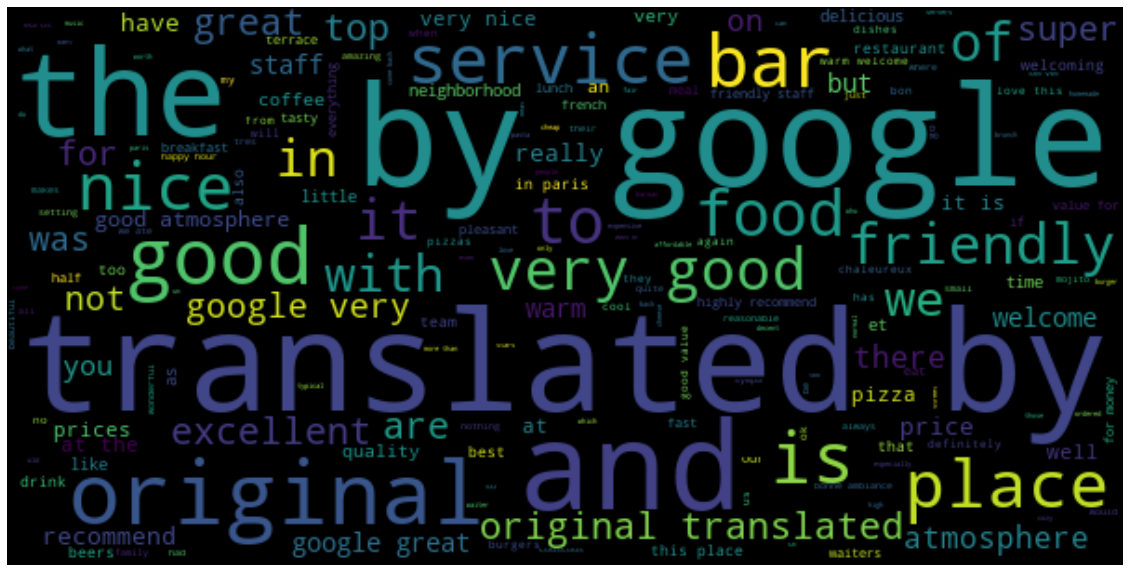

In [11]:
import matplotlib.pyplot as plt
# create a figure
fig, ax = plt.subplots(1,1, figsize = (20,20))
# add interpolation = bilinear to smooth things out
plt.imshow(wordcloud, interpolation='bilinear')
# and remove the axis
plt.axis("off") 

In [12]:
print(list(WordCloud().stopwords))

['http', 'at', 'would', 'hers', 'down', 'some', 'doing', "she'll", "haven't", 'i', 'into', 'did', 'like', 'other', 'was', 'of', 'is', 'its', 'our', "they'll", 'about', 'themselves', 'both', 'theirs', 'am', 'why', "you're", 'cannot', "hadn't", 'yourselves', 'from', 'out', 'and', 'too', 'whom', 'herself', "that's", 'they', "why's", 'being', 'in', "i'll", 'have', "let's", "i've", 'r', "they'd", 'not', 'once', 'when', "don't", 'any', 'above', 'we', 'further', "when's", 'through', 'his', "didn't", "doesn't", 'the', 'me', 'ought', 'having', 'which', 'just', 'same', 'were', 'while', 'where', "where's", 'who', 'you', "i'd", 'itself', 'all', "mustn't", "you've", "she'd", "weren't", 'k', 'ours', 'below', "won't", 'there', 'until', 'otherwise', 'nor', 'can', 'should', 'my', 'so', 'but', 'between', "hasn't", "shan't", "it's", "he's", 'since', 'ourselves', 'again', 'up', 'however', 'a', 'off', "we'd", 'to', "they're", 'else', 'after', "isn't", 'www', "he'd", "we've", "aren't", "who's", 'yourself', 

In [13]:
# transform the text into a list of words
words_list = text.split(' ')
# define the list of words you want to remove from the text
stopwords = ['','et','not','on',' ','i','we', 'it', ',','(original)','…','google)','(translated','(Translated by Google)','the', 'of', 'and', 'is','to','in','a','from','by','that', 'with', 'this', 'as', 'an', 'are','its', 'at', 'for']
# use a python list comprehension to remove the stopwords from words_list
words_without_stopwords = [ word for word in words_list if word not in stopwords ]


In [14]:
Counter(words_without_stopwords).most_common()

[('good', 77),
 ('very', 64),
 ('nice', 32),
 ('great', 28),
 ('bar', 27),
 ('friendly', 25),
 ('place', 22),
 ('food', 18),
 ('service', 18),
 ('super', 18),
 ('was', 18),
 ('excellent', 17),
 ('atmosphere', 15),
 ('warm', 15),
 ('staff', 13),
 ('top', 12),
 ('but', 12),
 ('have', 11),
 ('there', 11),
 ('really', 11),
 ('you', 10),
 ('!', 10),
 ('service,', 9),
 ('recommend', 9),
 ('well', 8),
 ('prices', 8),
 ('welcome', 8),
 ('love', 8),
 ('like', 8),
 ('paris', 8),
 ('little', 8),
 ('pizza', 8),
 ('highly', 7),
 ('best', 7),
 ('lunch', 6),
 ("it's", 6),
 ('also', 6),
 ('value', 6),
 ('our', 6),
 ('if', 6),
 ('everything', 6),
 ('quality', 6),
 ('food,', 6),
 ('place.', 6),
 ('coffee', 6),
 ('too', 6),
 ('french', 6),
 ('atmosphere,', 5),
 ('come', 5),
 ('place,', 5),
 ('drink', 5),
 ('when', 5),
 ('nice.', 5),
 ('neighborhood', 5),
 ('happy', 5),
 ('has', 5),
 ('my', 5),
 ('go', 5),
 ('will', 5),
 ('they', 5),
 ('us', 5),
 ('cool', 5),
 ('eat', 5),
 ('definitely', 5),
 ('price.', 5

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

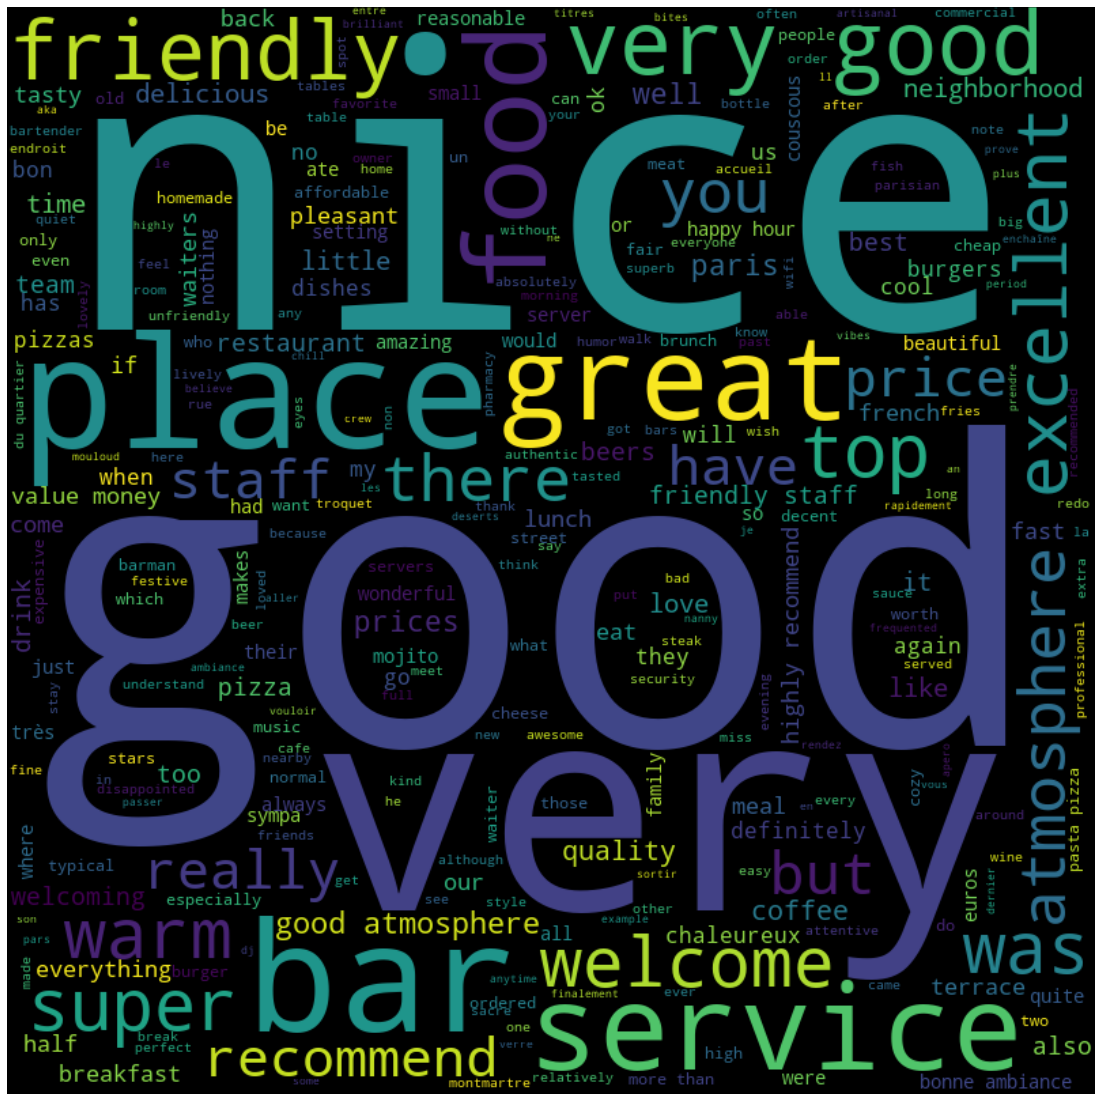

In [27]:
from wordcloud import WordCloud
# Instantiate a new wordcloud.
wordcloud = WordCloud(
        random_state = 8,
        normalize_plurals = False,
        width = 800, 
        height= 800,
        max_words = 300,
        stopwords = [])

# Transform the list of words back into a string 
text_without_stopwords  = ' '.join(words_without_stopwords)

# Apply the wordcloud to the text.
wordcloud.generate(text_without_stopwords)

# And plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,1, figsize = (20,20))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") 
plt.savefig("wordcloud.png") 

from google.colab import files
plt.savefig("wordcloud.png")
files.download("wordcloud.png") 

In [16]:
from google.colab import files
plt.savefig("wordcloud.png")
files.download("wordcloud.png") 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 432x288 with 0 Axes>

In [18]:
!pip install nltk 

In [19]:
import nltk
nltk.download('popular')

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gazetteers.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/genesis.zip.
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gutenberg.zip.
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/inaugural.zip.
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/movie_reviews.zip.
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/names.zip.
[nltk_data]    | Downloading package shakespeare to /root/nltk_data...
[nlt

True

In [20]:
from nltk.tokenize import WordPunctTokenizer
from collections import Counter

from nltk.tokenize import WordPunctTokenizer

text = text_without_stopwords 

tokens = WordPunctTokenizer().tokenize(text)
print(Counter(tokens).most_common(40))


[('.', 150), (',', 145), ('good', 84), ('!', 74), ('very', 65), ('nice', 40), ('place', 38), ('bar', 36), ('service', 33), ('great', 32), ('friendly', 32), ('food', 29), ('atmosphere', 25), ('top', 20), ('excellent', 19), ('super', 18), ('was', 18), ('staff', 18), ('recommend', 17), ('welcome', 17), ('warm', 17), ('you', 14), ("'", 14), ('there', 14), ('...', 14), ('but', 12), ('(', 11), ('have', 11), ('price', 11), ('really', 11), ('well', 10), ('prices', 10), ('paris', 10), ('pizza', 10), ('quality', 9), ('coffee', 9), ('delicious', 8), ('neighborhood', 8), ('it', 8), ('love', 8)]


Some words are better taken together: New York, Happy end, Wall street, Linear regression etc ... . When tokenizing we want to consider all possible adjacent pairs of words in the text. We can do this with the NLTK ngrams function

In [21]:
from nltk import ngrams

text = text_without_stopwords.lower()

# Tokenize
tokens = WordPunctTokenizer().tokenize(text)
unigrams = WordPunctTokenizer().tokenize(text)
# bigrams 
bigrams = [w for w in  ngrams(tokens,n=2)]
print(bigrams)

print()
bigrams = ['_'.join(bg) for bg in bigrams]
print(bigrams)


[('passer', 'prendre'), ('prendre', 'un'), ('un', 'verre'), ('verre', 'rapidement'), ('rapidement', 'entre'), ('entre', '2'), ('2', 'rendez'), ('rendez', '-'), ('-', 'vous'), ('vous', 'finalement'), ('finalement', 'ne'), ('ne', 'plus'), ('plus', 'vouloir'), ('vouloir', 'en'), ('en', 'sortir'), ('sortir', '.'), ('.', 'aller'), ('aller', 'un'), ('un', 'dernier'), ('dernier', 'son'), ('son', 'je'), ('je', 'pars'), ('pars', 'le'), ('le', 'barman'), ('barman', 'aka'), ('aka', 'dj'), ('dj', 'enchaîne'), ('enchaîne', 'les'), ('les', 'titres'), ('titres', 'very'), ('very', 'good'), ('good', 'atmosphere'), ('atmosphere', 'très'), ('très', 'bonne'), ('bonne', 'ambiance'), ('ambiance', 'place'), ('place', 'well'), ('well', 'frequented'), ('frequented', ','), (',', 'relatively'), ('relatively', 'fast'), ('fast', 'service'), ('service', ','), (',', 'good'), ('good', 'atmosphere'), ('atmosphere', ','), (',', 'recommend'), ('recommend', '😉'), ('😉', 'good'), ('good', 'music'), ('music', '&'), ('&', 'c

# and for trigrams 

In [22]:
trigrams = ['_'.join(w) for w in  ngrams(tokens,n=3)]

print(trigrams)

['passer_prendre_un', 'prendre_un_verre', 'un_verre_rapidement', 'verre_rapidement_entre', 'rapidement_entre_2', 'entre_2_rendez', '2_rendez_-', 'rendez_-_vous', '-_vous_finalement', 'vous_finalement_ne', 'finalement_ne_plus', 'ne_plus_vouloir', 'plus_vouloir_en', 'vouloir_en_sortir', 'en_sortir_.', 'sortir_._aller', '._aller_un', 'aller_un_dernier', 'un_dernier_son', 'dernier_son_je', 'son_je_pars', 'je_pars_le', 'pars_le_barman', 'le_barman_aka', 'barman_aka_dj', 'aka_dj_enchaîne', 'dj_enchaîne_les', 'enchaîne_les_titres', 'les_titres_very', 'titres_very_good', 'very_good_atmosphere', 'good_atmosphere_très', 'atmosphere_très_bonne', 'très_bonne_ambiance', 'bonne_ambiance_place', 'ambiance_place_well', 'place_well_frequented', 'well_frequented_,', 'frequented_,_relatively', ',_relatively_fast', 'relatively_fast_service', 'fast_service_,', 'service_,_good', ',_good_atmosphere', 'good_atmosphere_,', 'atmosphere_,_recommend', ',_recommend_😉', 'recommend_😉_good', '😉_good_music', 'good_mus

In [ ]:
text = text.lower()
unigrams = WordPunctTokenizer().tokenize(text)
bigrams = ['_'.join(w) for w in  ngrams(unigrams,n=2)]
trigrams = ['_'.join(w) for w in  ngrams(unigrams,n=3)]

In [ ]:
tokens = unigrams + bigrams + trigrams 

In [ ]:
print(f"we have a total of {len(tokens)} tokens, including: \n- {len(unigrams)} unigrams \n- {len(bigrams)} bigrams \n- {len(trigrams)} trigrams. ")

we have a total of 2500 tokens, including: 
- 2500 unigrams 
- 2499 bigrams 
- 2498 trigrams. 


In [23]:
Counter(tokens).most_common(100)

[('.', 150),
 (',', 145),
 ('good', 84),
 ('!', 74),
 ('very', 65),
 ('nice', 40),
 ('place', 38),
 ('bar', 36),
 ('service', 33),
 ('great', 32),
 ('friendly', 32),
 ('food', 29),
 ('atmosphere', 25),
 ('top', 20),
 ('excellent', 19),
 ('super', 18),
 ('was', 18),
 ('staff', 18),
 ('recommend', 17),
 ('welcome', 17),
 ('warm', 17),
 ('you', 14),
 ("'", 14),
 ('there', 14),
 ('...', 14),
 ('but', 12),
 ('(', 11),
 ('have', 11),
 ('price', 11),
 ('really', 11),
 ('well', 10),
 ('prices', 10),
 ('paris', 10),
 ('pizza', 10),
 ('quality', 9),
 ('coffee', 9),
 ('delicious', 8),
 ('neighborhood', 8),
 ('it', 8),
 ('love', 8),
 ('like', 8),
 ('little', 8),
 ('time', 8),
 ('welcoming', 7),
 ('beers', 7),
 ('also', 7),
 ('highly', 7),
 ('best', 7),
 ('drink', 7),
 ('team', 7),
 ('restaurant', 7),
 ('too', 7),
 ('-', 6),
 ('fast', 6),
 ('come', 6),
 ('back', 6),
 (')', 6),
 ('tasty', 6),
 ('pleasant', 6),
 ('!!!', 6),
 ('breakfast', 6),
 ('lunch', 6),
 ('s', 6),
 ('value', 6),
 ('money', 6),
 (

In [24]:
df = data
df

,id_review,caption,relative_date,retrieval_date,rating,username,n_review_user,n_photo_user,url_user
0,ChdDSUhNMG9nS0VJQ0FnSURtel82TXlRRRAB,Passer prendre un verre rapidement entre 2 rendez-vous et finalement ne plus vouloir en sortir. Aller un dernier son et je pars et le barman aka Dj enchaîne les titres,a day ago,2022-02-14 17:36:20.640681,5.0,Bolus Jonathan Kopdas,0,0,https://www.google.com/maps/contrib/104745591529904122578/reviews?hl=en-GB
1,ChdDSUhNMG9nS0VJQ0FnSURtcTlIZjFRRRAB,NaN,5 days ago,2022-02-14 17:36:20.643246,5.0,A A,0,0,https://www.google.com/maps/contrib/109010883926058002463/reviews?hl=en-GB
2,ChZDSUhNMG9nS0VJQ0FnSURteTd6Sk9BEAE,NaN,5 days ago,2022-02-14 17:36:20.647339,5.0,Bismuth Jennifer,0,0,https://www.google.com/maps/contrib/116256923366228944356/reviews?hl=en-GB
3,ChdDSUhNMG9nS0VJQ0FnSURtdGNmQXdRRRAB,NaN,a week ago,2022-02-14 17:36:20.650482,5.0,Championnet Carrelages,0,0,https://www.google.com/maps/contrib/109468437566041816416/reviews?hl=en-GB
4,ChdDSUhNMG9nS0VJQ0FnSURtb2MtMG5BRRAB,(Translated by Google) Very good atmosphere (Original) Très bonne ambiance,2 weeks ago,2022-02-14 17:36:20.653129,4.0,salem ousmail,0,0,https://www.google.com/maps/contrib/112077418104835202006/reviews?hl=en-GB
...,...,...,...,...,...,...,...,...,...
442,ChZDSUhNMG9nS0VJQ0FnSURzLVBPV1RREAE,"(Translated by Google) Great restaurant, very nice. Top service. The pizzas, a delight for a fair price. …",a year ago,2022-02-14 17:42:08.880422,5.0,Adeline Brunière,0,0,https://www.google.com/maps/contrib/113959710363232575897/reviews?hl=en-GB
443,ChdDSUhNMG9nS0VJQ0FnSURzcU5XS3B3RRAB,(Translated by Google) Good pizza to be in France but nothing ... Excessive prices but I think it is normal in Paris (a pizza 15 euros and a bottle of water 7 euros I think it's a rip off) …,a year ago,2022-02-14 17:42:08.883842,4.0,Aurora l,0,0,https://www.google.com/maps/contrib/112596743770313098424/reviews?hl=en-GB
444,ChZDSUhNMG9nS0VJQ0FnSUNzcGJuc0NnEAE,(Translated by Google) Pleasant setting in an old pharmacy very well reinvested. The welcome is warm and the dishes delicious (pasta and pizza). To try ! …,2 years ago,2022-02-14 17:42:08.886957,5.0,Nouch L.,0,0,https://www.google.com/maps/contrib/117022274796111735109/reviews?hl=en-GB
445,ChdDSUhNMG9nS0VJQ0FnSURNNXFMV3ZBRRAB,"The food was great! we ordered one pizza and two pastas, and the service was excellent as well",2 years ago,2022-02-14 17:42:15.184593,5.0,anna chalari,0,0,https://www.google.com/maps/contrib/117266783639191760404/reviews?hl=en-GB


In [ ]:
df1 = df[['username','rating','caption']]
df2 = df1.rename(columns={"caption": "text"})

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 447 entries, 0 to 446
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   username  447 non-null    object 
 1   rating    447 non-null    float64
 2   text      204 non-null    object 
dtypes: float64(1), object(2)
memory usage: 10.6+ KB


In [ ]:
df2.dropna()

,username,rating,text
0,Bolus Jonathan Kopdas,5.0,Passer prendre un verre rapidement entre 2 rendez-vous et finalement ne plus vouloir en sortir. Aller un dernier son et je pars et le barman aka Dj enchaîne les titres
4,salem ousmail,4.0,(Translated by Google) Very good atmosphere (Original) Très bonne ambiance
5,Cyril Cyril,5.0,"(Translated by Google) Place well frequented, relatively fast service, good atmosphere, I recommend …"
6,Diego Martinez Rego,4.0,😉
7,Laura Tenchio,5.0,Good music & chill vibes. I‘ll come back anytime again
...,...,...,...
442,Adeline Brunière,5.0,"(Translated by Google) Great restaurant, very nice. Top service. The pizzas, a delight for a fair price. …"
443,Aurora l,4.0,(Translated by Google) Good pizza to be in France but nothing ... Excessive prices but I think it is normal in Paris (a pizza 15 euros and a bottle of water 7 euros I think it's a rip off) …
444,Nouch L.,5.0,(Translated by Google) Pleasant setting in an old pharmacy very well reinvested. The welcome is warm and the dishes delicious (pasta and pizza). To try ! …
445,anna chalari,5.0,"The food was great! we ordered one pizza and two pastas, and the service was excellent as well"


In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [ ]:
#Add a couple of punctuation signs with multi charaters as stopwords to the nlp spacy mode
nlp.Defaults.stop_words.add("`,")
nlp.Defaults.stop_words.add("``")
nlp.Defaults.stop_words.add("(Translated")
nlp.Defaults.stop_words.add("by")
nlp.Defaults.stop_words.add("Google)")
nlp.Defaults.stop_words.add("(Original)")
nlp.Defaults.stop_words.add("Translated")
nlp.Defaults.stop_words.add("Google")
nlp.Defaults.stop_words.add("Original")
nlp.Defaults.stop_words.add("translate")
nlp.Defaults.stop_words.add("Google")


In [ ]:
def preprocess(text):
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not (token.is_stop or token.is_punct)]
    return ' '.join(tokens)

In [ ]:
text = '''These are the good times; Leave your cares behind'''
print(preprocess(text))

good time leave care


In [ ]:
#df2['processed_text'] = df2.text.apply(lambda txt : preprocess(txt))
#df2['processed_text']
df2['text'].str.len()
df2['text'].fillna('', inplace=True)

In [ ]:
df2['processed_text'] = df2.text.apply(lambda txt : preprocess(txt))
#df2['processed_text']

In [ ]:
df2

,username,rating,text,processed_text
0,Bolus Jonathan Kopdas,5.0,Passer prendre un verre rapidement entre 2 rendez-vous et finalement ne plus vouloir en sortir. Aller un dernier son et je pars et le barman aka Dj enchaîne les titres,Passer prendre un verre rapidement entre 2 rendez vous et finalement ne plus vouloir en sortir Aller un derni son et je par et le barman aka Dj enchaîne les titre
1,A A,5.0,,
2,Bismuth Jennifer,5.0,,
3,Championnet Carrelages,5.0,,
4,salem ousmail,4.0,(Translated by Google) Very good atmosphere (Original) Très bonne ambiance,translate Google good atmosphere original Très bonne ambiance
...,...,...,...,...
442,Adeline Brunière,5.0,"(Translated by Google) Great restaurant, very nice. Top service. The pizzas, a delight for a fair price. …",translate Google great restaurant nice service pizza delight fair price
443,Aurora l,4.0,(Translated by Google) Good pizza to be in France but nothing ... Excessive prices but I think it is normal in Paris (a pizza 15 euros and a bottle of water 7 euros I think it's a rip off) …,translate Google good pizza France excessive price think normal Paris pizza 15 euro bottle water 7 euro think rip
444,Nouch L.,5.0,(Translated by Google) Pleasant setting in an old pharmacy very well reinvested. The welcome is warm and the dishes delicious (pasta and pizza). To try ! …,translate Google pleasant set old pharmacy reinveste welcome warm dish delicious pasta pizza try
445,anna chalari,5.0,"The food was great! we ordered one pizza and two pastas, and the service was excellent as well",food great order pizza pasta service excellent
